# CNN视觉识别与目标检测主实验

本 notebook 只覆盖当前要先完成的 CNN 部分：

- 任务一 1：MNIST CNN 图像识别
- 任务二 1：Pascal VOC 2007 CNN/YOLO 目标检测

SNN 部分暂时不在本 notebook 中实现。

## 0. 环境与路径

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'proj_sim':
    PROJECT_ROOT = ROOT.parent
else:
    PROJECT_ROOT = ROOT
    sys.path.insert(0, str(PROJECT_ROOT / 'proj_sim'))

OUTPUT_DIR = PROJECT_ROOT / 'proj_sim' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MNIST_ROOT = PROJECT_ROOT / 'proj_sim' / 'mnist_dataset'
MNIST_TEST_DIR = PROJECT_ROOT / 'proj_sim' /  'MNIST-Test'

VOC_ROOT = PROJECT_ROOT / 'proj_sim' / 'VOCdevkit' / 'VOC2007trainval'
VOC_TEST_ROOT = PROJECT_ROOT / 'proj_sim' / 'VOCdevkit' / 'VOC2007test'

# 如果还没把原来的 VOC2007 改名成 VOC2007trainval，就临时兼容旧路径。
if not VOC_ROOT.exists():
    VOC_ROOT = PROJECT_ROOT / 'proj_sim' / 'VOCdevkit' / 'VOC2007'
if not VOC_TEST_ROOT.exists():
    VOC_TEST_ROOT = VOC_ROOT

print('project root:', PROJECT_ROOT)
print('mnist root:', MNIST_ROOT)
print('output dir:', OUTPUT_DIR)

project root: /home/mesonluuuu/courses/cs231
mnist root: /home/mesonluuuu/courses/cs231/proj_sim/mnist_dataset
output dir: /home/mesonluuuu/courses/cs231/proj_sim/outputs


In [2]:
import torch

from mnist_cnn import (
    LeNetMNIST,
    evaluate,
    make_loaders,
    make_mnist_splits,
    plot_loss_curves,
    plot_prediction_examples,
    save_checkpoint,
    set_seed,
    train_model,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(42)
print('device:', DEVICE)

device: cuda


## 1. CNN 图像识别：MNIST

### 1.1 数据集划分

将 MNIST 原始训练集与测试集合并后，按 5:1:1 随机划分为训练集、验证集、测试集(五折交叉随机验证)。图像大小为 28x28，单通道灰度，共 10 类。

In [3]:
train_set, val_set, test_set = make_mnist_splits(root=str(MNIST_ROOT), split=(5, 1, 1), seed=42)
loaders = make_loaders(train_set, val_set, test_set, batch_size=128, num_workers=2)

print('train:', len(train_set))
print('val:  ', len(val_set))
print('test: ', len(test_set))

train: 50000
val:   10000
test:  10000


### 1.2 网络结构

使用 LeNet 风格 CNN：

- Conv2d: 1 -> 32, kernel=3, padding=1, ReLU, 2x2 MaxPool
- Conv2d: 32 -> 64, kernel=3, padding=1, ReLU, 2x2 MaxPool
- Flatten
- Linear: 64*7*7 -> 128, ReLU, Dropout(0.25)
- Linear: 128 -> 10

损失函数为交叉熵，优化器为 Adam。

In [4]:
model = LeNetMNIST(num_classes=10)
print(model)
num_params = sum(p.numel() for p in model.parameters())
print('parameters:', num_params)

LeNetMNIST(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
parameters: 421642


### 1.3 训练与测试集准确率

In [5]:
history = train_model(
    model,
    loaders,
    epochs=5,
    lr=1e-3,
    device=DEVICE,
    weight_decay=1e-4,
)

test_loss, test_acc = evaluate(model, loaders['test'], device=DEVICE)
print(f'test loss: {test_loss:.4f}')
print(f'test accuracy: {test_acc:.4%}')

epoch 01: train loss 0.3515, train acc 0.8903, val loss 0.0882, val acc 0.9729
epoch 02: train loss 0.0924, train acc 0.9720, val loss 0.0580, val acc 0.9821
epoch 03: train loss 0.0657, train acc 0.9797, val loss 0.0477, val acc 0.9854
epoch 04: train loss 0.0526, train acc 0.9837, val loss 0.0521, val acc 0.9838
epoch 05: train loss 0.0445, train acc 0.9863, val loss 0.0474, val acc 0.9871
test loss: 0.0396
test accuracy: 98.6700%


checkpoint: /home/mesonluuuu/courses/cs231/proj_sim/outputs/mnist_cnn.pt
loss figure: /home/mesonluuuu/courses/cs231/proj_sim/outputs/mnist_loss.png
sample figure: /home/mesonluuuu/courses/cs231/proj_sim/outputs/mnist_examples.png


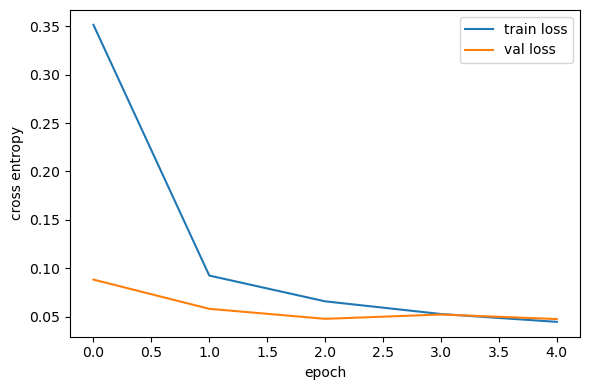

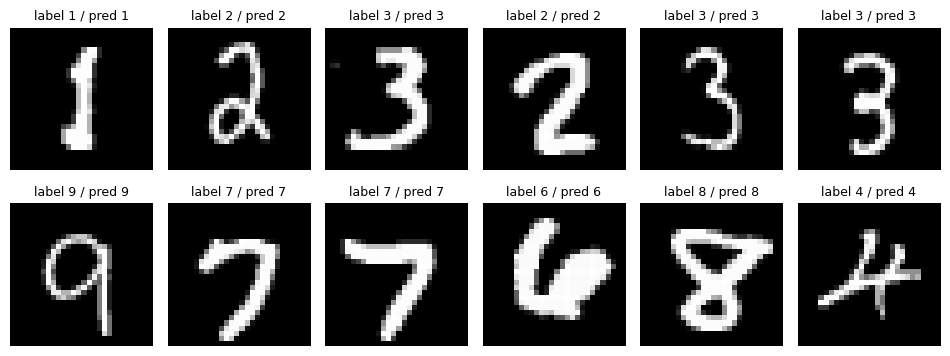

In [6]:
ckpt_path = save_checkpoint(model, history, OUTPUT_DIR / 'mnist_cnn.pt')
loss_fig = plot_loss_curves(history, OUTPUT_DIR / 'mnist_loss.png')
sample_fig = plot_prediction_examples(model, test_set, OUTPUT_DIR / 'mnist_examples.png', device=DEVICE, count=12)

print('checkpoint:', ckpt_path)
print('loss figure:', loss_fig)
print('sample figure:', sample_fig)

### 1.4 手写画板实时分类 UI

（不通过图片文件夹测试）启动一个交互式 UI：左侧为 28x28 黑色画板，拖动鼠标绘制白色数字；右侧实时显示 0-9 的预测概率柱状图，概率最高的类别为红色；底部显示最终预测结果。UI 还提供清除按钮和笔画粗细滑块。

运行前请确保上一步已经保存 `proj_sim/outputs/mnist_cnn.pt`。

In [24]:
import subprocess
import sys

# 在 notebook 中启动外部 tkinter 窗口。
# 如果你在远程无图形界面服务器上运行，需要在本地 Python 环境运行同一条命令。
ui_script = PROJECT_ROOT / 'proj_sim' / 'mnist_draw_ui.py'
process = subprocess.Popen([sys.executable, str(ui_script)])
print('MNIST draw UI started:', ui_script)
print('Process id:', process.pid)

MNIST draw UI started: /home/mesonluuuu/courses/cs231/proj_sim/mnist_draw_ui.py
Process id: 2062440


/home/mesonluuuu/courses/cs231/proj_sim/mnist_draw_ui.py:192: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  tensor = torch.tensor(list(self.image.getdata()), dtype=torch.float32)


## 2. CNN 目标检测：Pascal VOC 2007

### 2.1 模型框架说明

本实验使用 YOLO 系列一阶段目标检测器。推荐默认 `yolov8n.pt` 作为 Tiny-YOLO 风格的小模型：

- Backbone：CSP/卷积特征提取网络，逐级提取多尺度语义特征。
- Neck/Head：融合多尺度特征并直接预测目标类别、置信度和边界框。
- Anchor：YOLOv8 为 anchor-free 设计；若换成 YOLOv3/Tiny-YOLO，则使用 anchor boxes。
- Loss：边界框回归损失、分类损失、目标置信度/分布相关损失组合。

`detection_cnn.py` 会把 VOC XML 标注转换为 YOLO 格式，然后训练并在 VOC test split 上报告 mAP。

In [5]:
from detection_cnn import predict_test_folder, summarize_map, train_yolo_voc

print('VOC train root exists:', VOC_ROOT.exists(), VOC_ROOT)
print('VOC test root exists: ', VOC_TEST_ROOT.exists(), VOC_TEST_ROOT)

VOC train root exists: True /home/mesonluuuu/courses/cs231/proj_sim/VOCdevkit/VOC2007trainval
VOC test root exists:  True /home/mesonluuuu/courses/cs231/proj_sim/VOCdevkit/VOC2007test


### 2.2 训练检测网络并记录 mAP

下面单元会训练 YOLO。第一次运行如果没有 `ultralytics`，先在当前 notebook 环境中安装：`pip install ultralytics`。如果课程时间有限，也可以先用较小的 `epochs=5` 做流程验证，再提高到 30 或更多。

In [ ]:
RUN_DETECTION_TRAINING = True  # 确认VOC路径后改成 True

if RUN_DETECTION_TRAINING:
    yolo_model, train_result, metrics = train_yolo_voc(
        voc_root=VOC_ROOT,
        eval_voc_root=VOC_TEST_ROOT,
        out_dir=OUTPUT_DIR / 'voc2007_yolo',
        model_name='yolov8n.pt',
        epochs=30,
        imgsz=640,
        batch=8,
        device=0 if DEVICE == 'cuda' else 'cpu',
    )
    print(summarize_map(metrics))
else:
    
    print('Detection training skipped. Set RUN_DETECTION_TRAINING = True after VOC_ROOT is correct.')

VOC split 'test' not found at /home/mesonluuuu/courses/cs231/proj_sim/VOCdevkit/VOC2007/ImageSets/Main/test.txt; using 'val' split instead.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/mesonluuuu/courses/cs231/proj_sim/outputs/voc2007_yolo/voc2007.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, m

### 2.3 VOC2007test 图像检测 UI

训练完成后，把 `WEIGHTS` 指向训练结果中的 `best.pt`，例如：

`proj_sim/outputs/voc2007_yolo/runs/yolo_voc2007/weights/best.pt`

启动一个交互式 UI：左侧显示 VOC2007test 图片和预测框，右侧显示置信度最高的 3 个检测结果及概率条。可以点击 Prev/Next 切换图片，Detect 重新识别当前图片。

In [6]:
import subprocess
import sys

WEIGHTS = OUTPUT_DIR / 'voc2007_yolo' / 'runs' / 'yolo_voc2007' / 'weights' / 'best.pt'
VOC_TEST_IMAGE_DIR = VOC_TEST_ROOT / 'JPEGImages'
ui_script = PROJECT_ROOT / 'proj_sim' / 'voc_detection_ui.py'

process = subprocess.Popen([
    sys.executable,
    str(ui_script),
    '--weights', str(WEIGHTS),
    '--image-dir', str(VOC_TEST_IMAGE_DIR),
    '--conf', '0.25',
    '--imgsz', '640',
    '--device', '0' if DEVICE == 'cuda' else 'cpu',
])
print('VOC detection UI started:', ui_script)
print('Image folder:', VOC_TEST_IMAGE_DIR)
print('Process id:', process.pid)

VOC detection UI started: /home/mesonluuuu/courses/cs231/proj_sim/voc_detection_ui.py
Image folder: /home/mesonluuuu/courses/cs231/proj_sim/VOCdevkit/VOC2007test/JPEGImages
Process id: 2734446


### 2.4 目标检测误差分析

本实验使用 YOLOv8n 在 Pascal VOC 2007 上训练 30 个 epoch。最终整体检测结果为：Precision = 0.9054，Recall = 0.8894，mAP@0.5 = 0.9507，mAP@0.5:0.95 = 0.7670。整体来看，模型在 IoU=0.5 的宽松定位标准下检测效果较好，但在更严格的 mAP@0.5:0.95 指标下仍有下降，说明主要误差仍来自边界框定位精度和复杂目标场景。

从类别结果看，train、horse、cat、dog、bicycle、aeroplane 等类别的 mAP@0.5 较高，通常超过 0.97，说明这些类别外观特征明显、目标轮廓较稳定，模型较容易识别。相对地，bottle、pottedplant、chair 等类别表现较弱，例如 pottedplant 的 mAP@0.5:0.95 约为 0.568，bottle 约为 0.646，chair 约为 0.706。这些类别常见问题是目标较小、形状细长、容易被遮挡，且背景中容易出现相似纹理，因此更容易发生漏检或定位偏差。

常见误差主要包括三类。第一是定位偏差：当目标边界不清晰、目标被遮挡或目标尺寸较小时，预测框可能只覆盖目标的一部分，或者包含过多背景区域，这会导致 mAP@0.5:0.95 下降。第二是类别混淆：外观相似或上下文接近的类别更容易混淆，例如 chair 和 sofa、car 和 bus、cat 和 dog 等。第三是漏检与误检：小目标、多目标密集场景和背景复杂图像中，模型可能漏掉低置信度目标；而当背景纹理与目标局部特征相似时，也可能产生错误检测框。

总体而言，YOLOv8n 作为轻量级 CNN 检测模型，在 VOC 2007 上能够取得较高 mAP@0.5，说明其具备较好的目标分类和粗定位能力。但由于模型规模较小，且 VOC 中存在小目标、遮挡和复杂背景，严格定位指标仍明显低于 mAP@0.5。后续若要进一步提升效果，可以尝试更大的 YOLO 模型、增加训练轮数、提高输入分辨率，或针对小目标类别进行数据增强。
